# Student Success Intelligence System

## Business Problem

Educational institutions often struggle to identify students who may require academic support before poor outcomes occur.

The objective of this analysis is to identify the key drivers of academic success and build an early-warning framework for identifying at-risk students.

## Objectives

- Understand student performance patterns
- Identify factors affecting final grades
- Explore attendance and failure impacts
- Discover characteristics of high-performing students
- Generate insights for intervention strategies

## Questions

1. What factors influence final grades?
2. Does attendance impact performance?
3. How important is study time?
4. Do previous failures predict future outcomes?
5. Which students should be flagged for intervention?

In [9]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

sns.set_style("whitegrid")

In [10]:
df = pd.read_csv("../data/students.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (649, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,0,yes,no,no,no,yes,yes,yes,no,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,no,yes,yes,yes,yes,yes,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,no,no,yes,yes,no,no,4,3,2,1,2,5,0,11,13,13


In [11]:
print("Missing Values")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

df.info()

Missing Values
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

Duplicate Rows: 0
<class 'pandas.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      649 non-null    str  
 1   sex         649 non-null    str  
 2   age         649 non-null    int64
 3   address     649 non-null    str  
 4   famsize     649 non-null    str  
 5   Pstatus     649 non-null    str  
 6   Medu        64

In [12]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000
mean,16.744222,2.514638,2.306626,1.568567,1.930663,0.221880,3.930663,3.180277,3.184900,1.502311,2.280431,3.536210,3.659476,11.399076,11.570108,11.906009
std,1.218138,1.134552,1.099931,0.748660,0.829510,0.593235,0.955717,1.051093,1.175766,0.924834,1.284380,1.446259,4.640759,2.745265,2.913639,3.230656
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,16.000000,2.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,2.000000,0.000000,10.000000,10.000000,10.000000
50%,17.000000,2.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,11.000000,11.000000,12.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,32.000000,19.000000,19.000000,19.000000


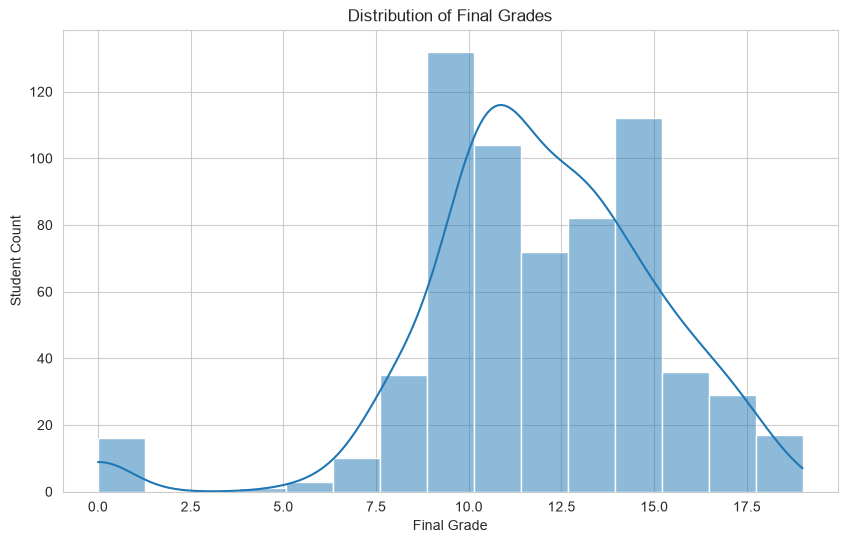

In [13]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["G3"],
    bins=15,
    kde=True
)

plt.title("Distribution of Final Grades")
plt.xlabel("Final Grade")
plt.ylabel("Student Count")

plt.show()

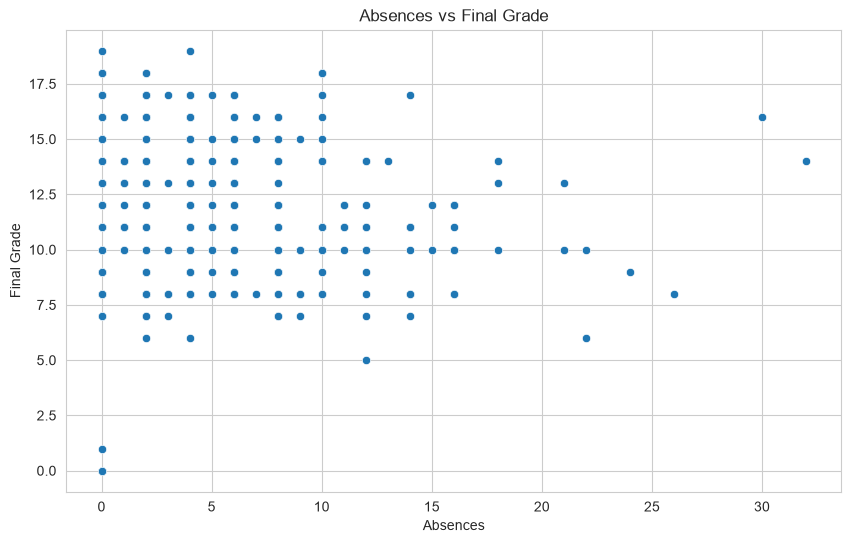

In [14]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="absences",
    y="G3"
)

plt.title("Absences vs Final Grade")
plt.xlabel("Absences")
plt.ylabel("Final Grade")

plt.show()

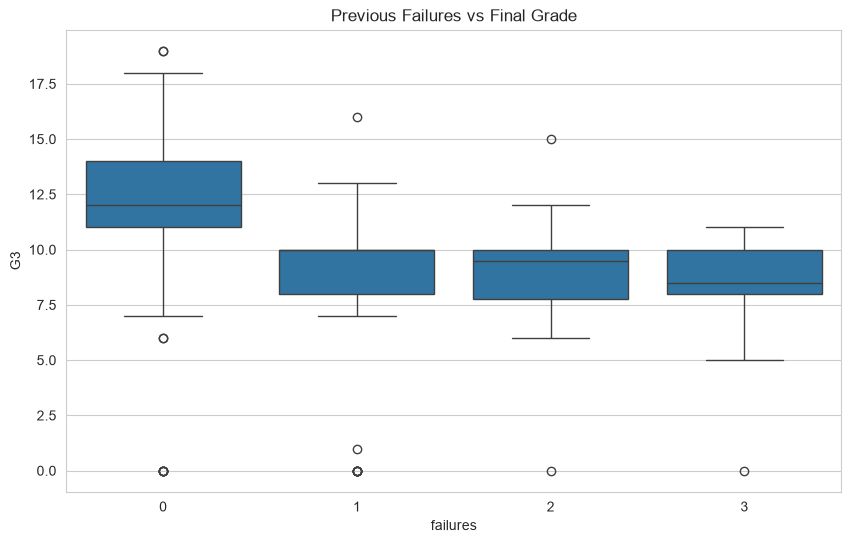

In [15]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="failures",
    y="G3"
)

plt.title("Previous Failures vs Final Grade")

plt.show()

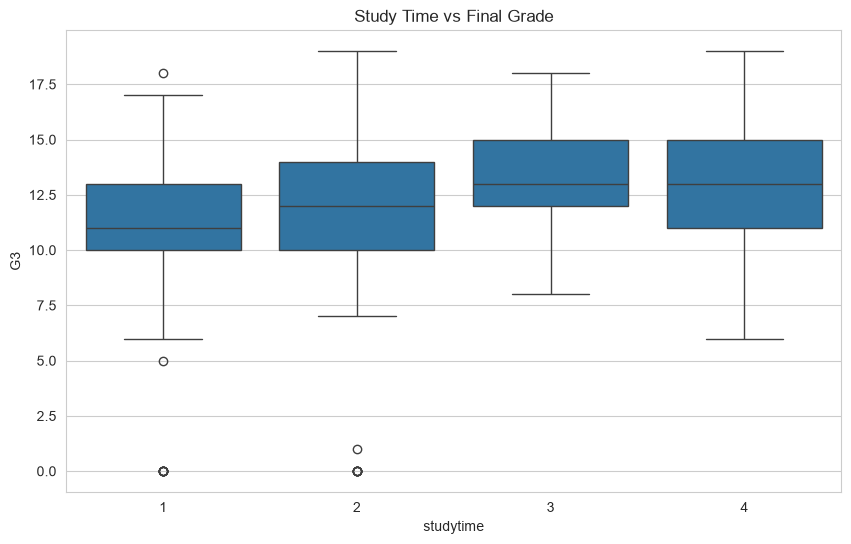

In [17]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="studytime",
    y="G3"
)

plt.title("Study Time vs Final Grade")

plt.show()

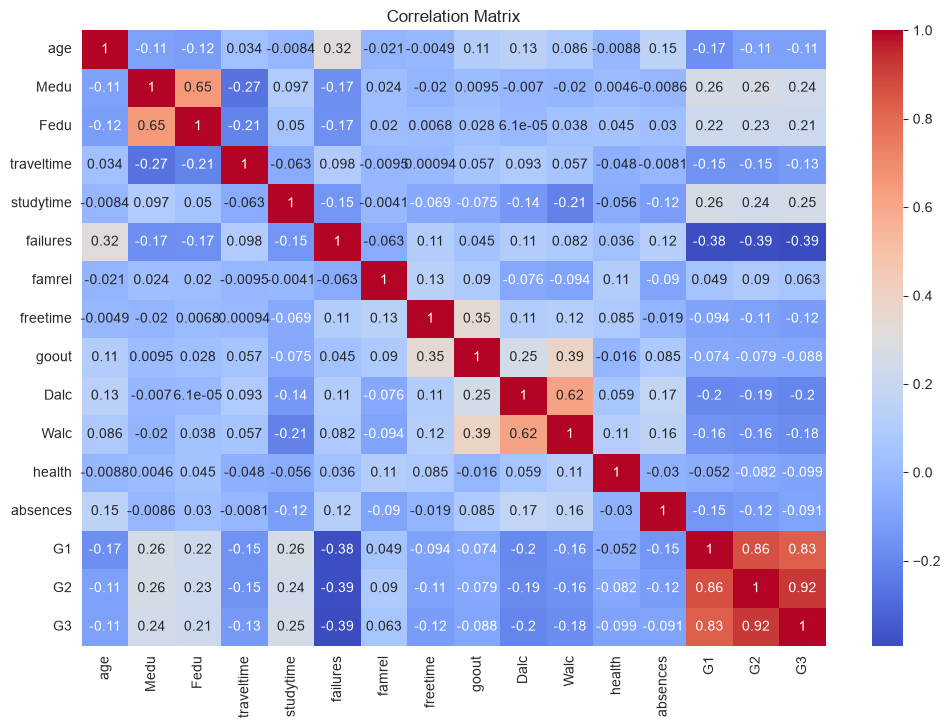

In [18]:
numeric_df = df.select_dtypes(include=np.number)

corr_matrix = numeric_df.corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    annot=True
)

plt.title("Correlation Matrix")

plt.show()

In [19]:
top_predictors = (
    numeric_df
    .corr()["G3"]
    .sort_values(ascending=False)
)

top_predictors

G3            1.000000
G2            0.918548
G1            0.826387
studytime     0.249789
Medu          0.240151
Fedu          0.211800
famrel        0.063361
goout        -0.087641
absences     -0.091379
health       -0.098851
age          -0.106505
freetime     -0.122705
traveltime   -0.127173
Walc         -0.176619
Dalc         -0.204719
failures     -0.393316
Name: G3, dtype: float64

In [20]:
high_performers = df[df["G3"] >= 16]

at_risk_students = df[df["G3"] < 10]

comparison = pd.DataFrame({
    "High Performers": [
        high_performers["absences"].mean(),
        high_performers["failures"].mean(),
        high_performers["studytime"].mean()
    ],
    "At Risk Students": [
        at_risk_students["absences"].mean(),
        at_risk_students["failures"].mean(),
        at_risk_students["studytime"].mean()
    ]
},
index=[
    "Average Absences",
    "Average Failures",
    "Average Study Time"
])

comparison

,High Performers,At Risk Students
Average Absences,2.585366,4.61
Average Failures,0.012195,0.75
Average Study Time,2.243902,1.61


# Key Findings

1. Previous failures are strongly associated with poor academic outcomes.

2. Attendance shows a negative relationship with final grades.

3. Earlier assessments (G1 and G2) are strong indicators of final performance.

4. High-performing students typically have fewer failures and more consistent academic records.

5. At-risk students can be identified before final examinations using academic history and attendance patterns.

# Next Steps

- Build engineered risk features
- Create student personas
- Develop risk classification logic
- Generate executive insights
- Produce automated reports